In [51]:
import sys
sys.path.append('../code')

import os

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import (make_network, set_train_parameters, simulate, gaussian_tuning,
                           StimSynapse, get_currents, IonotropicSynapse, get_prior_dict)
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA

from tqdm import tqdm

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [54]:
# data_path =  '/users/ntolley/data/ntolley/dendractor/intrinsic_permutations/random_initialization'
# data_path =  '/users/ntolley/data/ntolley/dendractor/intrinsic_permutations_somaampa_dendnmda/random_initialization'
# data_path = '/users/ntolley/data/ntolley/dendractor/extrinsic_permutations_subnet_highprob_cuecontext/random_initialization'
data_path = '/users/ntolley/data/ntolley/dendractor/extrinsic_permutations_subnet_highprob_cuecontext_ring_k10/random_initialization/'

file_list = os.listdir(data_path)

random_init_dict = dict()
for file_idx in tqdm(range(len(file_list))):
    with open(f'{data_path}/{file_list[file_idx]}', 'rb') as f:
        res_dict = pickle.load(f)
    
    random_init_dict[res_dict['name']] = res_dict


100%|██████████| 1/1 [00:01<00:00,  1.16s/it]


In [55]:
print(list(random_init_dict.keys()))

['contextdend_cuedend']


In [56]:
# res_dict = random_init_dict['Esoma_Isoma']
# res_dict = random_init_dict['Esoma_Idend']
# res_dict = random_init_dict['Esoma_Isomadend']

# res_dict = random_init_dict['Edend_Isoma']
# res_dict = random_init_dict['Edend_Idend']
# res_dict = random_init_dict['Edend_Isomadend']

# res_dict = random_init_dict['Esomadend_Isoma']
# res_dict = random_init_dict['Esomadend_Idend']
# res_dict = random_init_dict['Esomadend_Isomadend']

res_dict = random_init_dict['contextdend_cuedend']


name = res_dict['name']
output_array = res_dict['output_array']
targets = res_dict['targets']
targets_stacked = res_dict['targets_stacked']
gid_ranges = res_dict['gid_ranges']
input_list = res_dict['input_list']
num_cond = input_list.shape[0]
print(name)

contextdend_cuedend


In [57]:
t_max = 1000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
# burn_in = 30_000 // downsample_factor
burn_in = 10_000 // downsample_factor

In [79]:
rate_gids = list(gid_ranges['E_rate'])
rates = output_array[:, rate_gids, :]

x_train = list()
target_train = list()
for sim_idx in range(0, output_array.shape[0], num_cond):
    temp_x_train_list = list()
    temp_target_train_list = list()
    # for cond_idx in range(num_cond):
    # for cond_idx in [0,1,4,5]:
    for cond_idx in [2,3]:
        temp_x_train_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], burn_in:])
        temp_target_train_list.append(targets_stacked[cond_idx, :, burn_in:])
    x_train.append(np.concatenate(temp_x_train_list, axis=1).T)
    target_train.append(np.concatenate(temp_target_train_list, axis=1).T)


num_model_sims = 5


error_list = list()
model = Ridge(alpha=2.0)
rate_fit = np.concatenate([x for x in x_train[:num_model_sims]])
target_fit = np.concatenate([y for y in target_train[:num_model_sims]])
model.fit(rate_fit, target_fit)

# for sim_idx in range(num_model_sims, len(x_train)):
for sim_idx in range(len(x_train)):
    rate_pred = x_train[sim_idx]
    y_pred = model.predict(rate_pred)


    error = np.mean(np.square(target_train[sim_idx] - y_pred))
    error_list.append(error)
print(error_list[:num_model_sims])
print(error_list[num_model_sims:])

[np.float64(0.387952851008949), np.float64(0.4931112104231503), np.float64(0.3737835232496141), np.float64(0.4031918196117922), np.float64(0.49815023160416844)]
[np.float64(0.4623600273509357), np.float64(0.515067643566595), np.float64(0.4885060405027944), np.float64(0.5148090278118453), np.float64(4.560954620858115)]


In [80]:
y_pred_list = list()
target_list = list()


val_idx = 8
sim_start_idx = val_idx * num_cond
for cond_idx in range(num_cond):
    rate_plot_data = output_array[sim_start_idx + cond_idx, gid_ranges['E_rate'], :].T
    y_pred = model.predict(rate_plot_data)

    y_pred_list.append(y_pred)
    target_list.append(res_dict['targets_stacked'][cond_idx, :, :].T)

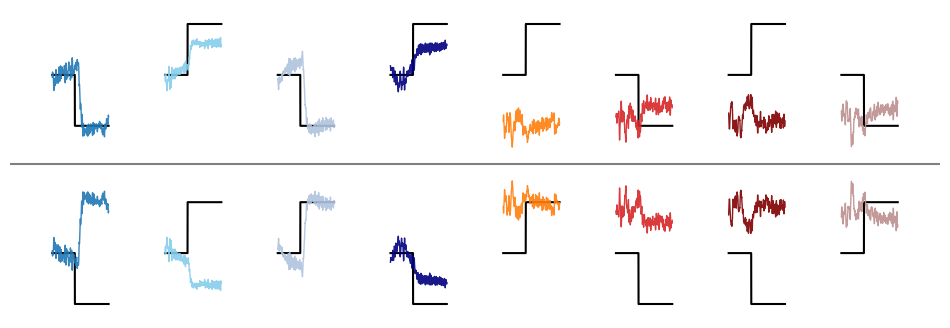

In [81]:
color_list = ['C0', 'skyblue', 'lightsteelblue', 'navy', 'C1', 'C3', 'maroon', 'rosybrown']
# time_offset = 3000
time_offset = 1000
y_offset = -7
# y_offset = -20
plt.figure(figsize=(12,4))

plot_burn_in = 2000
for cond_idx in range(num_cond):
    x_offset = time_offset * cond_idx
    
    plt.plot(time_vec[plot_burn_in:] + x_offset, target_list[cond_idx][plot_burn_in:-1, 0], color='k')
    plt.plot(time_vec[plot_burn_in:] + x_offset, y_pred_list[cond_idx][plot_burn_in:-1, 0], color=color_list[cond_idx], alpha=0.9, linewidth=1)

    plt.plot(time_vec[plot_burn_in:] + x_offset, target_list[cond_idx][plot_burn_in:-1, 1] + y_offset, color='k')
    plt.plot(time_vec[plot_burn_in:] + x_offset, y_pred_list[cond_idx][plot_burn_in:-1, 1] + y_offset, color=color_list[cond_idx], alpha=0.9, linewidth=1)


    plt.axis('off')
plt.axhline(y_offset/2, color='grey', linestyle='-')
# plt.axvline((time_offset * 4) - 500, color='grey', linestyle='-')
# plt.savefig('full_trajectory_set.svg')

In [82]:
input_names = [
    'Pro (-1,-1)', 'Pro (1,1)', 'Pro (-1,1)', 'Pro (1,-1)',
    'Anti (-1,-1)', 'Anti (1,1)', 'Anti (-1,1)', 'Anti (1,-1)']

In [83]:
gid_ranges

{'E': range(0, 50),
 'I': range(50, 75),
 'context': range(75, 100),
 'cue': range(100, 125),
 'E_rate': range(125, 175),
 'I_rate': range(175, 200)}

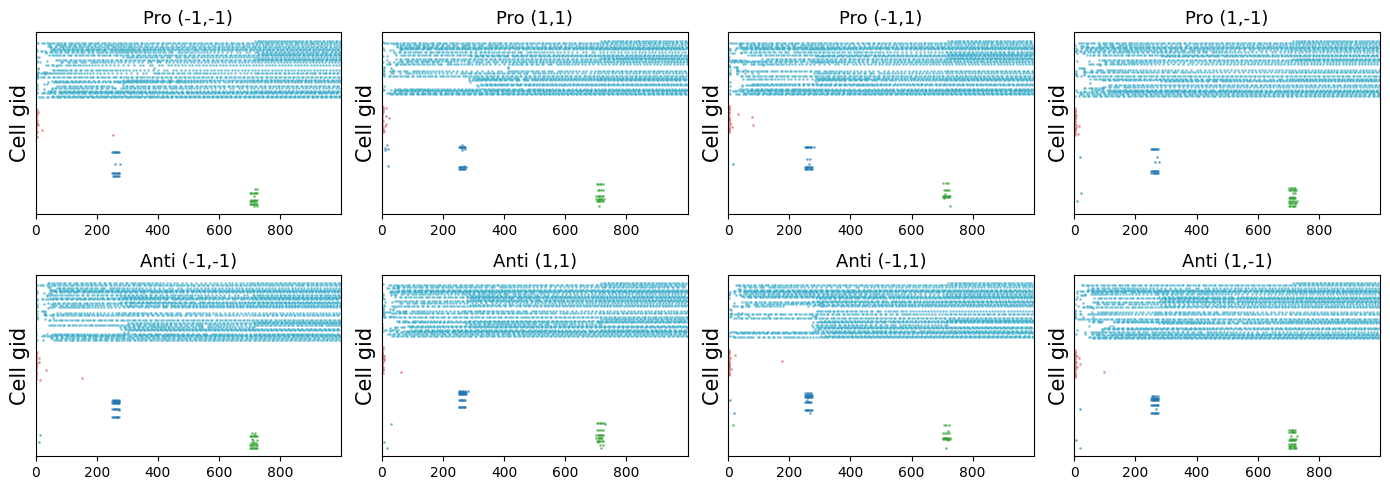

In [85]:
fontsize = 15
ticksize = 10
labelsize=13
threshold = 0.0

spike_color_dict = {'E': '#37abc8', 'I': '#d35f5f', 'context': '#1f77b4', 'cue': '#2ca02c'}
plt.figure(figsize=(14,5))
for plot_idx, sim_idx in enumerate(range(num_cond)):
    # sim_idx *= num_cond
    # sim_idx += 10
    
    plt.subplot(2,4, plot_idx+1)
    s = output_array[sim_idx, :]
    above_threshold = s > threshold
    spike_gids, spike_times = np.where(np.diff(above_threshold.astype(int), axis=1) == 1)

    for type_idx, (name, cell_range) in enumerate(gid_ranges.items()):
        if name not in ['output', 'E_rate', 'I_rate']:
            mask = np.isin(spike_gids, cell_range)
            plt.scatter(spike_times[mask] * dt, -spike_gids[mask] - type_idx * 10, label=name, s=1, alpha=0.5, color=spike_color_dict[name])
    plt.ylabel('Cell gid', fontsize=fontsize)
    plt.yticks([])
    plt.xlim(0, time_vec[-1])
    # plt.axvline(500 * dt, color='k', linestyle='--')
    plt.title(input_names[plot_idx], fontsize=labelsize)
    plt.tight_layout()
    # plt.xlim(650, 700)

In [64]:
pca = PCA()
pca.fit(np.concatenate(x_train))

PCA()

In [65]:
def make_trajectory_figure(points1, points2, points3, points4, start_idx, end_idx, ax, dim1=0, dim2=1, dim3=2,
                           color1='C0', color2='C9', color3='C1', color4='C3',
                           label1=None, label2=None, label3=None, label4=None):
    ax.grid(False)
    # ax.set_xlabel(f'PC{dim1+1}', fontsize=labelsize)
    # ax.set_ylabel(f'PC{dim2+1}', fontsize=labelsize)
    # ax.set_zlabel(f'PC{dim3+1}', fontsize=labelsize)

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])


    ax.plot(points1[start_idx:end_idx,dim1], points1[start_idx:end_idx, dim2], points1[start_idx:end_idx, dim3], color=color1, label=label1)
    ax.plot(points2[start_idx:end_idx,dim1], points2[start_idx:end_idx, dim2], points2[start_idx:end_idx, dim3], color=color2, label=label2)
    ax.plot(points3[start_idx:end_idx,dim1], points3[start_idx:end_idx, dim2], points3[start_idx:end_idx, dim3], color=color3, label=label3)
    ax.plot(points4[start_idx:end_idx,dim1], points4[start_idx:end_idx, dim2], points4[start_idx:end_idx, dim3], color=color4, label=label4)


    ax.scatter(points1[start_idx,dim1], points1[start_idx, dim2], points1[start_idx, dim3], color='k', marker='*', s=50)
    ax.scatter(points2[start_idx,dim1], points2[start_idx, dim2], points2[start_idx, dim3], color='k', marker='*', s=50)
    ax.scatter(points3[start_idx,dim1], points3[start_idx, dim2], points3[start_idx, dim3], color='k', marker='*', s=50)
    ax.scatter(points4[start_idx,dim1], points4[start_idx, dim2], points4[start_idx, dim3], color='k', marker='*', s=50)

    ax.scatter(points1[end_idx,dim1], points1[end_idx, dim2], points1[end_idx, dim3], color=color1, s=100, edgecolor='k')
    ax.scatter(points2[end_idx,dim1], points2[end_idx, dim2], points2[end_idx, dim3], color=color2, s=100, edgecolor='k')
    ax.scatter(points3[end_idx,dim1], points3[end_idx, dim2], points3[end_idx, dim3], color=color3, s=100, edgecolor='k')
    ax.scatter(points4[end_idx,dim1], points4[end_idx, dim2], points4[end_idx, dim3], color=color4, s=100, edgecolor='k')


    ax.view_init(elev=30., azim=-200, roll=0)

    # plt.tight_layout()
    # plt.show()

In [31]:
num_repeats = output_array.shape[0] // num_cond

In [32]:
ticksize = 11
labelsize = 15

sim_idx1, sim_idx2, sim_idx3, sim_idx4 = 0, 1, 2, 3
sim_idx5, sim_idx6, sim_idx7, sim_idx8 = 4, 5, 6, 7

# sim_idx1, sim_idx2, sim_idx3, sim_idx4 = 0, 1, 0,1
# sim_idx5, sim_idx6, sim_idx7, sim_idx8 = 2,3,2,3

cue_idx = 2800

points1_list, points2_list, points3_list, points4_list = list(), list(), list(), list()
points5_list, points6_list, points7_list, points8_list = list(), list(), list(), list()

for repeat_idx in range(0, num_repeats):
    sim_offset = repeat_idx * num_cond
    points1_list.append(pca.transform(output_array[sim_idx1, gid_ranges['E_rate'], :].T))
    points2_list.append(pca.transform(output_array[sim_idx2, gid_ranges['E_rate'], :].T))
    points3_list.append(pca.transform(output_array[sim_idx3, gid_ranges['E_rate'], :].T))
    points4_list.append(pca.transform(output_array[sim_idx4, gid_ranges['E_rate'], :].T))

    points5_list.append(pca.transform(output_array[sim_idx5, gid_ranges['E_rate'], :].T))
    points6_list.append(pca.transform(output_array[sim_idx6, gid_ranges['E_rate'], :].T))
    points7_list.append(pca.transform(output_array[sim_idx7, gid_ranges['E_rate'], :].T))
    points8_list.append(pca.transform(output_array[sim_idx8, gid_ranges['E_rate'], :].T))

points1 = np.mean(points1_list, axis=0)
points2 = np.mean(points2_list, axis=0)
points3 = np.mean(points3_list, axis=0)
points4 = np.mean(points4_list, axis=0)

points5 = np.mean(points5_list, axis=0)
points6 = np.mean(points6_list, axis=0)
points7 = np.mean(points7_list, axis=0)
points8 = np.mean(points8_list, axis=0)

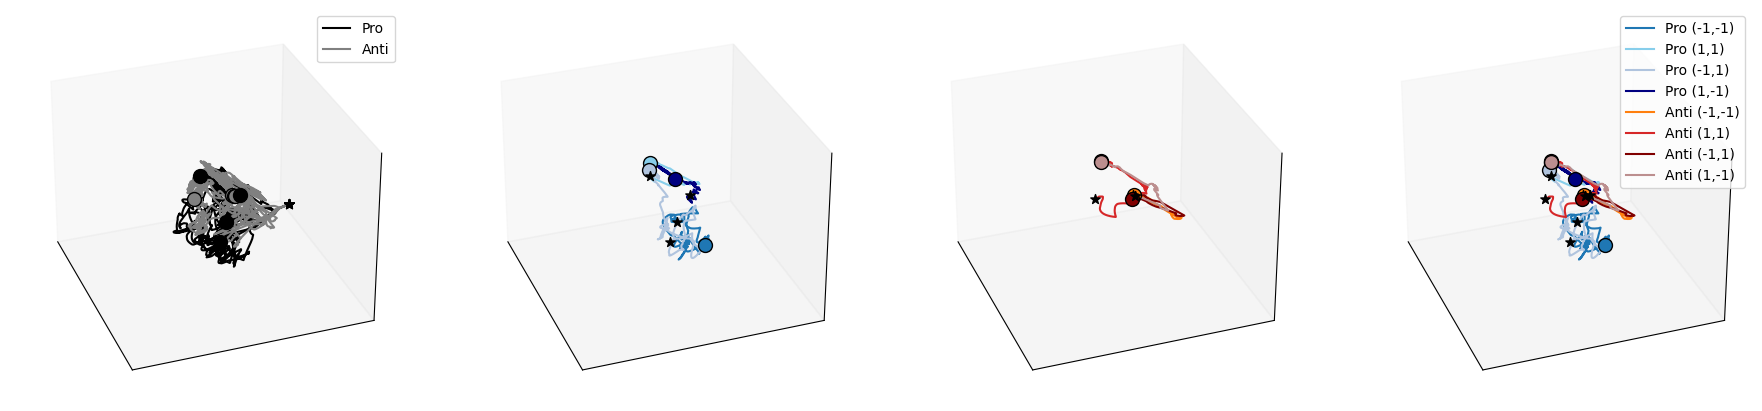

In [33]:
dim1, dim2, dim3 = 0,1,2

fig = plt.figure(figsize=(18,4), constrained_layout=True)
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')


# make_trajectory_figure(points1, points5, points1, points5, 0, cue_idx, ax1, dim1, dim2, dim3,
#                        color1='k', color2='grey', color3='k', color4='grey', label1='Pro', label2='Anti')

make_trajectory_figure(points1, points2, points3, points4, 0, cue_idx, ax1, dim1, dim2, dim3,
                       color1='k', color2='k', color3='k', color4='k', label1='Pro')

make_trajectory_figure(points5, points6, points7, points8, 0, cue_idx, ax1, dim1, dim2, dim3,
                       color1='grey', color2='grey', color3='grey', color4='grey', label1='Anti')

make_trajectory_figure(points1, points2, points3, points4, cue_idx, cue_idx+1200, ax2, dim1, dim2, dim3,
                       color1='C0', color2='skyblue', color3='lightsteelblue', color4='navy',
                       label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4])

make_trajectory_figure(points5, points6, points7, points8, cue_idx, cue_idx+1200, ax3, dim1, dim2, dim3,
                       color1='C1', color2='C3', color3='maroon', color4='rosybrown',
                       label1=input_names[sim_idx5], label2=input_names[sim_idx6], label3=input_names[sim_idx7], label4=input_names[sim_idx8])


make_trajectory_figure(points1, points2, points3, points4, cue_idx, cue_idx+1200, ax4, dim1, dim2, dim3,
                       color1='C0', color2='skyblue', color3='lightsteelblue', color4='navy',
                       label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4])

make_trajectory_figure(points5, points6, points7, points8, cue_idx, cue_idx+1200, ax4, dim1, dim2, dim3,
                       color1='C1', color2='C3', color3='maroon', color4='rosybrown',
                       label1=input_names[sim_idx5], label2=input_names[sim_idx6], label3=input_names[sim_idx7], label4=input_names[sim_idx8])

limits = [(-3, 5), (-4, 4), (-3, 2)]
# limits = [(-9, 5), (-5, 6), (-5, 3.4)]
for ax_plot in [ax1, ax2, ax3, ax4]:
    ax_plot.set_xlim(limits[0])
    ax_plot.set_ylim(limits[1])
    ax_plot.set_zlim(limits[2])

ax1.legend(loc='upper right')
# ax2.legend(loc='upper right')
# ax3.legend(loc='upper right')
ax4.legend(loc='upper right')
# plt.savefig('cuesoma_context_soma_trajectory1.svg')


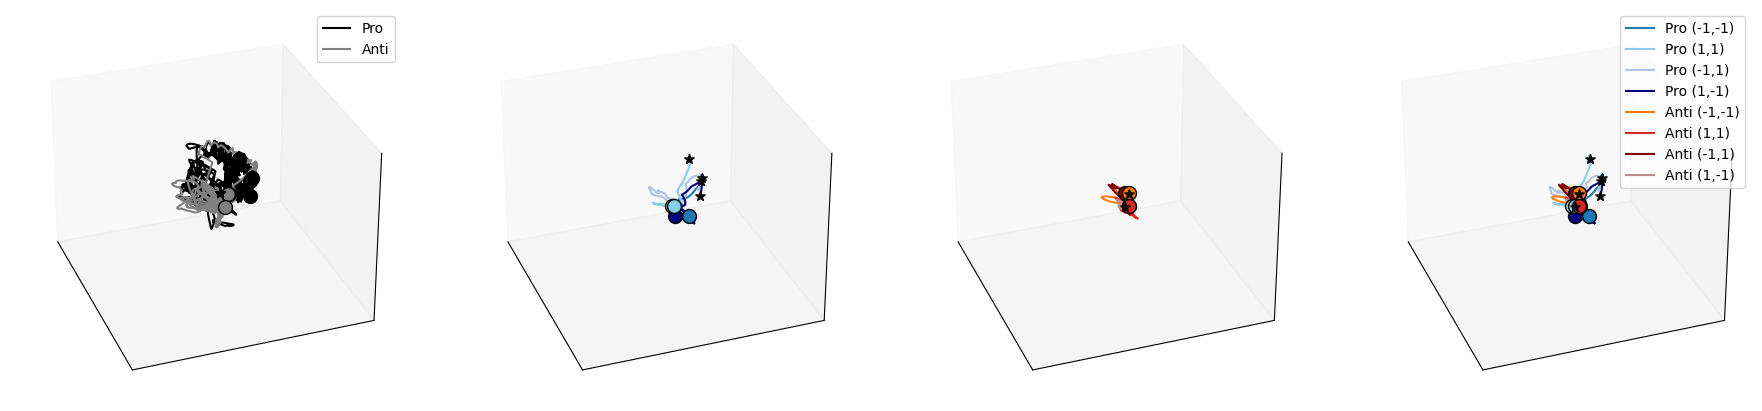

In [34]:
dim1, dim2, dim3 = 3,4,5

fig = plt.figure(figsize=(18,4), constrained_layout=True)
ax1 = fig.add_subplot(141, projection='3d')
ax2 = fig.add_subplot(142, projection='3d')
ax3 = fig.add_subplot(143, projection='3d')
ax4 = fig.add_subplot(144, projection='3d')


# make_trajectory_figure(points1, points5, points1, points5, 0, cue_idx, ax1, dim1, dim2, dim3,
#                        color1='k', color2='grey', color3='k', color4='grey', label1='Pro', label2='Anti')

make_trajectory_figure(points1, points2, points3, points4, 0, cue_idx, ax1, dim1, dim2, dim3,
                       color1='k', color2='k', color3='k', color4='k', label1='Pro')

make_trajectory_figure(points5, points6, points7, points8, 0, cue_idx, ax1, dim1, dim2, dim3,
                       color1='grey', color2='grey', color3='grey', color4='grey', label1='Anti')

make_trajectory_figure(points1, points2, points3, points4, cue_idx, cue_idx+1200, ax2, dim1, dim2, dim3,
                       color1='C0', color2='skyblue', color3='lightsteelblue', color4='navy',
                       label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4])

make_trajectory_figure(points5, points6, points7, points8, cue_idx, cue_idx+1200, ax3, dim1, dim2, dim3,
                       color1='C1', color2='C3', color3='maroon', color4='rosybrown',
                       label1=input_names[sim_idx5], label2=input_names[sim_idx6], label3=input_names[sim_idx7], label4=input_names[sim_idx8])


make_trajectory_figure(points1, points2, points3, points4, cue_idx, cue_idx+1200, ax4, dim1, dim2, dim3,
                       color1='C0', color2='skyblue', color3='lightsteelblue', color4='navy',
                       label1=input_names[sim_idx1], label2=input_names[sim_idx2], label3=input_names[sim_idx3], label4=input_names[sim_idx4])

make_trajectory_figure(points5, points6, points7, points8, cue_idx, cue_idx+1200, ax4, dim1, dim2, dim3,
                       color1='C1', color2='C3', color3='maroon', color4='rosybrown',
                       label1=input_names[sim_idx5], label2=input_names[sim_idx6], label3=input_names[sim_idx7], label4=input_names[sim_idx8])

limits = [(-3, 5), (-4, 4), (-3, 2)]
# limits = [(-9, 5), (-5, 6), (-5, 3.4)]
for ax_plot in [ax1, ax2, ax3, ax4]:
    ax_plot.set_xlim(limits[0])
    ax_plot.set_ylim(limits[1])
    ax_plot.set_zlim(limits[2])

ax1.legend(loc='upper right')
# ax2.legend(loc='upper right')
# ax3.legend(loc='upper right')
ax4.legend(loc='upper right')
# plt.savefig('cuesoma_context_soma_trajectory1.svg')
